[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/kulinskij-tech/Synergetics/blob/main/syn_py/syn_02_stability_bifurcations.ipynb)


# 02. Stability, critical slowing down, and bifurcations

_Graduate course: Introduction to Synergetics · English draft_

> **Guiding question:** What changes mathematically when a macroscopic state loses stability?

**Notebook contract.** Run from top to bottom. All parameters are dimensionless unless stated otherwise. Explain every diagnostic you use; a visually attractive trajectory is not by itself evidence of self-organization.


## Learning outcomes

By the end of this module, you should be able to:

- classify fixed points from Jacobian eigenvalues
- recognize saddle-node, transcritical, pitchfork, and Hopf normal forms
- measure critical slowing down and order-parameter scaling


## Prerequisite bridge: fixed points, Jacobians, and eigenmodes
Consider the system of ODE:
$$\dot{\mathbf{x}} = \mathbf{F}(\mathbf{x};\mu)$$
where $\mathbf{x}$ is the state vector and $\mu$ are parameters. A fixed point $\mathbf{x}_*$ satisfies $\mathbf{F}(\mathbf{x}_*;\mu)=0$. Write a small perturbation as $\boldsymbol\xi=\mathbf{x}-\mathbf{x}_*$. Taylor expansion gives

$$\dot{\boldsymbol\xi}=J_*\boldsymbol\xi+O(\|\boldsymbol\xi\|^2),\qquad
(J_*)_{ij}=\left.\frac{\partial F_i}{\partial x_j}\right|_{\mathbf{x}_*}.$$

An eigenmode behaves locally as $e^{\lambda t}$. Negative real parts imply decay, positive real parts imply instability, and a nonzero imaginary part produces oscillation. Linearization is local: zero real parts require nonlinear terms, and eigenvalues alone do not describe distant attractors or basin boundaries.


## Classification of planar fixed points

Before studying how equilibria change at a bifurcation, we need a visual language for their local behavior. For a smooth autonomous system

$$\dot x=f(x,y),\qquad \dot y=g(x,y),$$

an equilibrium $(x_*,y_*)$ is an intersection of the **nullclines** $f=0$ and $g=0$. On $f=0$ the velocity is vertical; on $g=0$ it is horizontal, except at equilibria where both components vanish. A nullcline is generally not a trajectory. Shift the equilibrium to the origin with $\boldsymbol\xi=(x-x_*,y-y_*)^T$. For a twice continuously differentiable vector field,

$$\dot{\boldsymbol\xi}=A\boldsymbol\xi+O(\|\boldsymbol\xi\|^2),\qquad
A=J_* = \begin{pmatrix}f_x&f_y\\g_x&g_y\end{pmatrix}_{(x_*,y_*)}.$$

For the linear system, a real eigenpair satisfies $A\mathbf v=\lambda\mathbf v$, and $\boldsymbol\xi(t)=c e^{\lambda t}\mathbf v$ lies on an invariant eigenvector line. With distinct real eigenvalues the general solution is

$$\boldsymbol\xi(t)=c_1e^{\lambda_1t}\mathbf v_1+c_2e^{\lambda_2t}\mathbf v_2.$$

Eigenvalues determine growth or decay; eigenvectors determine directions. At a saddle the stable and unstable eigenspaces are one-dimensional. At a stable node the entire plane is the stable subspace, even though only two eigenvector lines are drawn. For a nonlinear saddle, the corresponding invariant curves are generally curved, tangent to these lines at the equilibrium.

Write

$$T=\operatorname{tr}A=a+d,\qquad D=\det A=ad-bc,\qquad Q=T^2-4D.$$

Here $D$ denotes a determinant, not the laser inversion from Module 01. Expanding $\det(\lambda I-A)=0$ gives

$$\lambda^2-T\lambda+D=0,\qquad
\lambda_\pm=\frac{T\pm\sqrt Q}{2},\qquad
T=\lambda_++\lambda_-,\quad D=\lambda_+\lambda_-.$$

This turns the eigenvalue classification into geometry in the $(T,D)$ plane. The parabola $D=T^2/4$ separates real from complex eigenvalues. For the linear flow, a small material area changes by the factor $e^{Tt}$; negative trace means area contraction, but does not alone imply attraction because a saddle can contract area while expanding in one direction.

| Conditions | Linear type | Behavior as $t\to+\infty$ |
|---|---|---|
| $D<0$ | Saddle | One growing and one decaying direction; unstable |
| $D>0,\ Q>0,\ T<0$ | Stable node (sink) | Both modes decay without oscillatory eigenmodes |
| $D>0,\ Q>0,\ T>0$ | Unstable node (source) | Both modes grow |
| $Q<0,\ T<0$ | Stable focus / spiral sink | Damped rotation toward the equilibrium |
| $Q<0,\ T>0$ | Unstable focus / spiral source | Growing rotation away from the equilibrium |
| $D>0,\ T=0$ | Linear center | Closed orbits; stable, but not asymptotically stable |
| $Q=0,\ T\ne0$ | Repeated-eigenvalue node | Star or defective node; sign of $T$ fixes stability |
| $D=0$ | At least one zero eigenvalue | Degenerate linear case; inspect the matrix and nonlinear terms |

“Stable” in the Lyapunov sense means sufficiently small perturbations remain small for all future time. “Asymptotically stable” additionally means they converge to the equilibrium. A center satisfies the first property but not the second. A sink need not have monotonically decreasing Euclidean distance at every instant; nonorthogonal eigenvectors can allow transient growth.


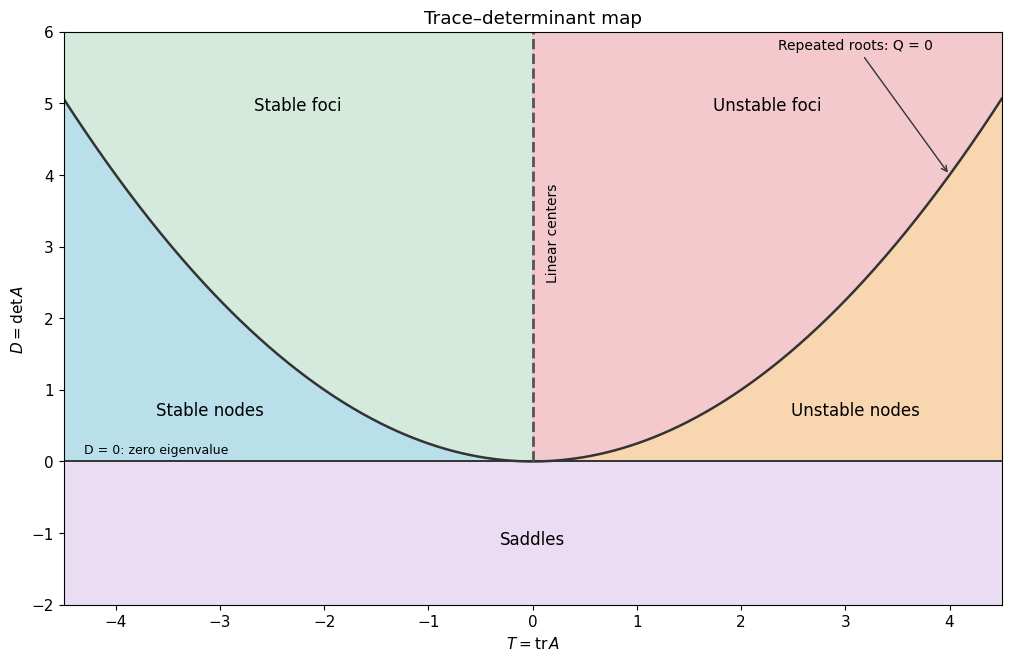

In [8]:
# planar-fixed-points-trace-diagram
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

pf_lang = "en"
def pf_text(en, ua):
    return ua if pf_lang == "uk" else en

pf_t = np.linspace(-4.5, 4.5, 701)
pf_d = np.linspace(-2.0, 6.0, 601)
pf_T, pf_D = np.meshgrid(pf_t, pf_d)
pf_regions = np.where(pf_D < 0, 0,
    np.where(pf_D < pf_T**2/4, np.where(pf_T < 0, 1, 2),
             np.where(pf_T < 0, 3, 4)))
pf_fig, pf_ax = plt.subplots(figsize=(10, 6.5), layout="constrained")
pf_ax.pcolormesh(pf_T, pf_D, pf_regions,
    cmap=ListedColormap(["#eadcf2", "#b9dfeb", "#f8d6af", "#d3eadc", "#f3c9ce"]),
    shading="auto", rasterized=True)
pf_ax.plot(pf_t, pf_t**2/4, color="#333333", lw=1.8)
pf_ax.axhline(0, color="#333333", lw=1.4)
pf_ax.plot([0, 0], [0, 6], color="#555555", lw=2, ls="--")
for tx, dy, en, ua in [
    (-3.1, .65, "Stable nodes", "Стійкі вузли"),
    (3.1, .65, "Unstable nodes", "Нестійкі вузли"),
    (-2.25, 4.9, "Stable foci", "Стійкі фокуси"),
    (2.25, 4.9, "Unstable foci", "Нестійкі фокуси"),
    (0, -1.15, "Saddles", "Сідла")]:
    pf_ax.text(tx, dy, pf_text(en, ua), ha="center", fontsize=12)
pf_ax.text(.13, 3.2, pf_text("Linear centers", "Лінійні центри"),
           rotation=90, va="center", fontsize=10)
pf_ax.annotate(pf_text("Repeated roots: Q = 0", "Кратні корені: Q = 0"),
    xy=(4.0, 4.0), xytext=(3.1, 5.75), ha="center",
    arrowprops=dict(arrowstyle="->", color="#333333"), fontsize=10)
pf_ax.text(-4.3, .12, pf_text("D = 0: zero eigenvalue", "D = 0: нульове власне значення"), fontsize=9)
pf_ax.set(xlim=(-4.5,4.5), ylim=(-2,6), xlabel=r"$T=\mathrm{tr}\,A$",
    ylabel=r"$D=\det A$", title=pf_text("Trace–determinant map", "Діаграма слід–визначник"))
pf_ax.grid(False)
plt.show()


### Reading the phase-portrait atlas

Each panel below shows $\dot{\boldsymbol\xi}=A\boldsymbol\xi$ in the same square. Arrows indicate forward time, the black dot marks an isolated equilibrium, and the title gives the eigenvalues. Blue dashed and orange dotted lines mark stable and unstable real eigenvector directions; they are not nullclines. The last panel has a whole line of equilibria, drawn in black. Compare geometry and time orientation, not streamline density: these plots do not encode probability or equal time intervals.

For $\lambda=\alpha\pm i\omega$, suitable real coordinates give

$$\dot u=\alpha u-\omega v,\quad \dot v=\omega u+\alpha v,
\qquad \dot r=\alpha r,\quad\dot\theta=\omega.$$

Thus $\alpha$ controls radial growth and $\omega$ controls rotation. In other linear coordinates the circles become ellipses. Trace and determinant do not fix the rotation direction or the eigenvector orientation: evaluate the vector field at a point to find the arrow direction.

For a repeated nonzero eigenvalue $\lambda=T/2$, distinguish $A=\lambda I$ (a **star node**, every line invariant) from a defective matrix with only one independent eigenvector. In Jordan coordinates the latter has

$$A=\begin{pmatrix}\lambda&1\\0&\lambda\end{pmatrix},\qquad
\boldsymbol\xi(t)=e^{\lambda t}\begin{pmatrix}u_0+t v_0\\v_0\end{pmatrix}.$$

The factor $t$ bends the trajectories but does not overcome exponential decay when $\lambda<0$. “Improper,” “degenerate,” and “defective” node terminology varies between textbooks; the number of eigenvectors is unambiguous. A repeated nonzero eigenvalue is still hyperbolic.

When $D=0$, the linear equilibrium is not isolated: its set is $\ker A$. At $T=D=0$, $A=0$ makes every point stationary, whereas a nonzero nilpotent matrix such as $\begin{pmatrix}0&1\\0&0\end{pmatrix}$ produces shear, $x=x_0+t y_0$, $y=y_0$. These cases cannot be distinguished from trace and determinant alone.


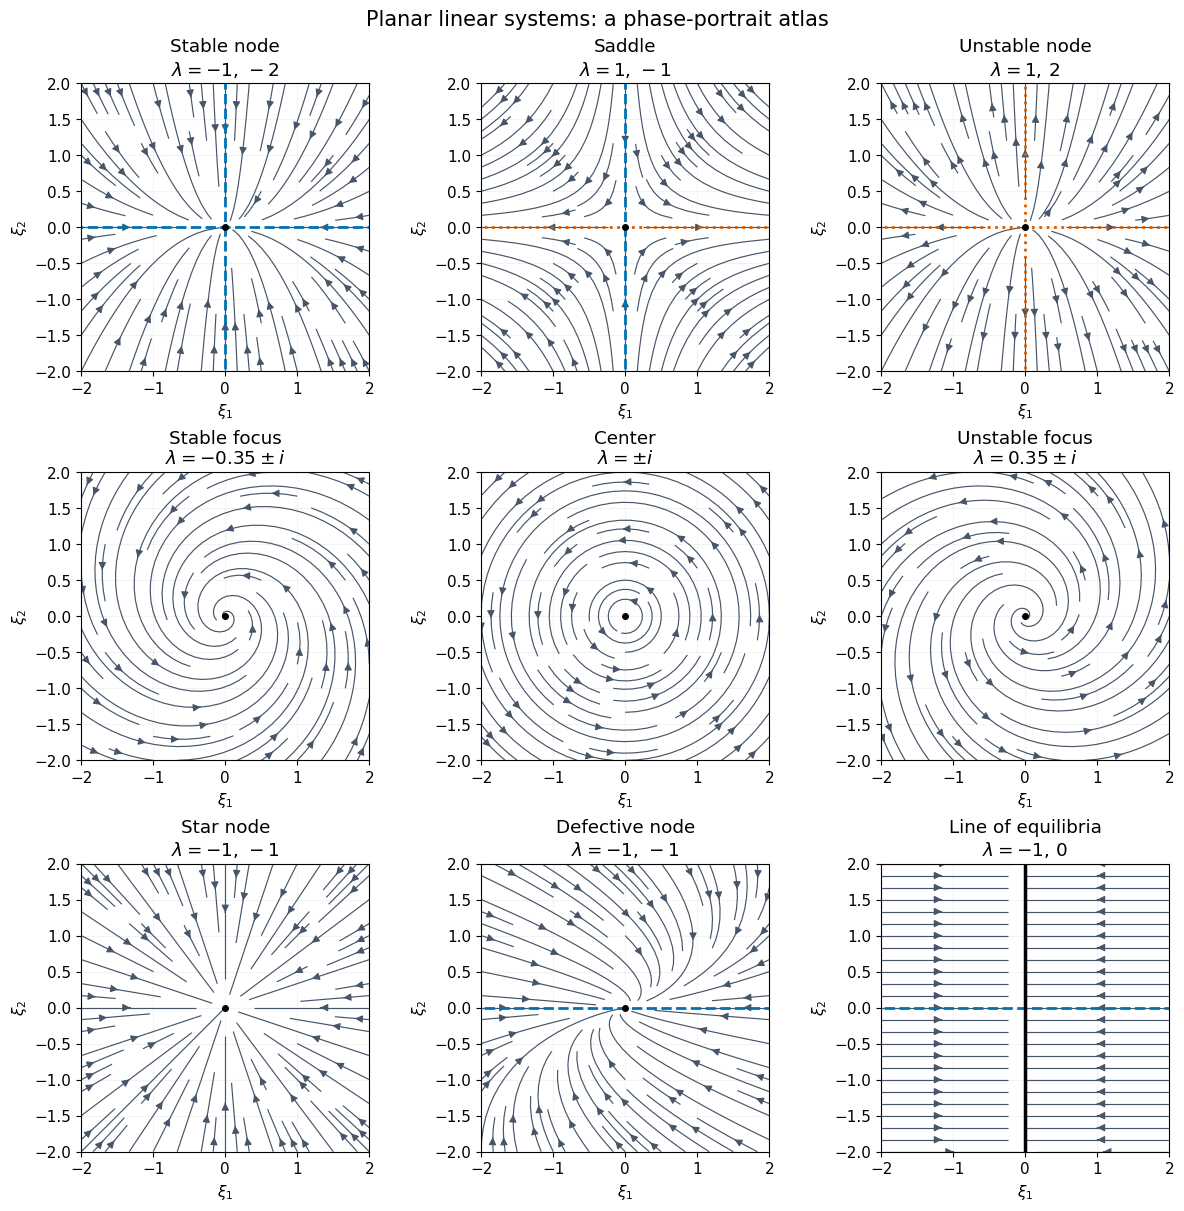

In [9]:
# planar-fixed-points-atlas
pf_cases = [
    ("Stable node", "Стійкий вузол", [[-1,0],[0,-2]], r"-1,\,-2"),
    ("Saddle", "Сідло", [[1,0],[0,-1]], r"1,\,-1"),
    ("Unstable node", "Нестійкий вузол", [[1,0],[0,2]], r"1,\,2"),
    ("Stable focus", "Стійкий фокус", [[-.35,-1],[1,-.35]], r"-0.35\pm i"),
    ("Center", "Центр", [[0,-1],[1,0]], r"\pm i"),
    ("Unstable focus", "Нестійкий фокус", [[.35,-1],[1,.35]], r"0.35\pm i"),
    ("Star node", "Зірковий вузол", [[-1,0],[0,-1]], r"-1,\,-1"),
    ("Defective node", "Дефектний вузол", [[-1,1],[0,-1]], r"-1,\,-1"),
    ("Line of equilibria", "Пряма рівноваг", [[-1,0],[0,0]], r"-1,\,0"),
]
pf_grid = np.linspace(-2, 2, 65)
pf_X, pf_Y = np.meshgrid(pf_grid, pf_grid)
pf_fig, pf_axes = plt.subplots(3,3,figsize=(12,12),layout="constrained")
for pf_ax, (pf_en, pf_ua, pf_matrix, pf_eiglabel) in zip(pf_axes.flat, pf_cases):
    pf_A = np.asarray(pf_matrix, dtype=float)
    pf_U = pf_A[0,0]*pf_X + pf_A[0,1]*pf_Y
    pf_V = pf_A[1,0]*pf_X + pf_A[1,1]*pf_Y
    pf_ax.streamplot(pf_grid, pf_grid, pf_U, pf_V, density=.85,
                     color="#475569", linewidth=.85, arrowsize=1.1)
    pf_values, pf_vectors = np.linalg.eig(pf_A)
    if np.all(np.abs(pf_values.imag) < 1e-10) and not np.allclose(pf_A, np.eye(2)*pf_A[0,0]):
        pf_seen = []
        for pf_value, pf_vector in zip(pf_values.real, pf_vectors.T.real):
            if abs(pf_value) < 1e-10:
                continue
            pf_vector = pf_vector / np.linalg.norm(pf_vector)
            if any(abs(np.dot(pf_vector, v)) > .9999 for v in pf_seen):
                continue
            pf_seen.append(pf_vector)
            pf_line = np.outer(np.linspace(-4,4,2), pf_vector)
            pf_ax.plot(pf_line[:,0], pf_line[:,1],
                color="#0072B2" if pf_value < 0 else "#D55E00",
                ls="--" if pf_value < 0 else ":", lw=2)
    if np.isclose(np.linalg.det(pf_A), 0):
        pf_ax.axvline(0, color="black", lw=2.5)
    else:
        pf_ax.plot(0,0,"ko",ms=4)
    pf_ax.set(xlim=(-2,2),ylim=(-2,2),xlabel=r"$\xi_1$",ylabel=r"$\xi_2$",
              title=pf_text(pf_en,pf_ua)+"\n"+r"$\lambda="+pf_eiglabel+"$")
    pf_ax.set_aspect("equal")
    pf_ax.grid(alpha=.15)
pf_fig.suptitle(pf_text("Planar linear systems: a phase-portrait atlas",
                       "Лінійні системи на площині: атлас фазових портретів"), fontsize=15)
plt.show()


### What linearization can and cannot decide

A fixed point is **hyperbolic** if all Jacobian eigenvalues have nonzero real parts. For a smooth vector field, the Hartman–Grobman theorem gives a local topological equivalence with the linearized flow. Thus a hyperbolic sink, source, or saddle retains its local stability character; it does not follow that nonlinear trajectories are exact ellipses or straight lines. Repeated eigenvalues with nonzero real part are allowed. At a nonhyperbolic point, nonlinear terms must be examined.

The following three systems all have the same Jacobian $\begin{pmatrix}0&-1\\1&0\end{pmatrix}$ at the origin:

$$\dot x=-y+\sigma x(x^2+y^2),\qquad
\dot y=x+\sigma y(x^2+y^2),\qquad \sigma\in\{-1,0,1\}.$$

Because $r\dot r=x\dot x+y\dot y$ and $r^2\dot\theta=x\dot y-y\dot x$,

$$\dot r=\sigma r^3,\qquad \dot\theta=1,\qquad
r(t)=\frac{r_0}{\sqrt{1-2\sigma r_0^2t}}.$$

For $\sigma=-1$ the origin attracts algebraically; for $\sigma=0$ it is a center; for $\sigma=1$ it repels. The last expression is used only before its denominator vanishes. Equal linear eigenvalues therefore do not settle nonlinear stability. The figure uses the exact solutions, avoiding numerical drift that might falsely turn a center into a spiral.

The boundaries also have different meanings. Crossing $Q=0$ with $T\ne0$ changes a node into a focus without losing stability. Crossing $D=0$ introduces a zero eigenvalue and can allow a steady-state bifurcation. Crossing $T=0$ at $D>0$ is a candidate Hopf crossing, but a Hopf bifurcation additionally requires a nonzero crossing speed and appropriate nonlinear nondegeneracy conditions. The trace–determinant picture alone does not prove that a limit cycle is born.


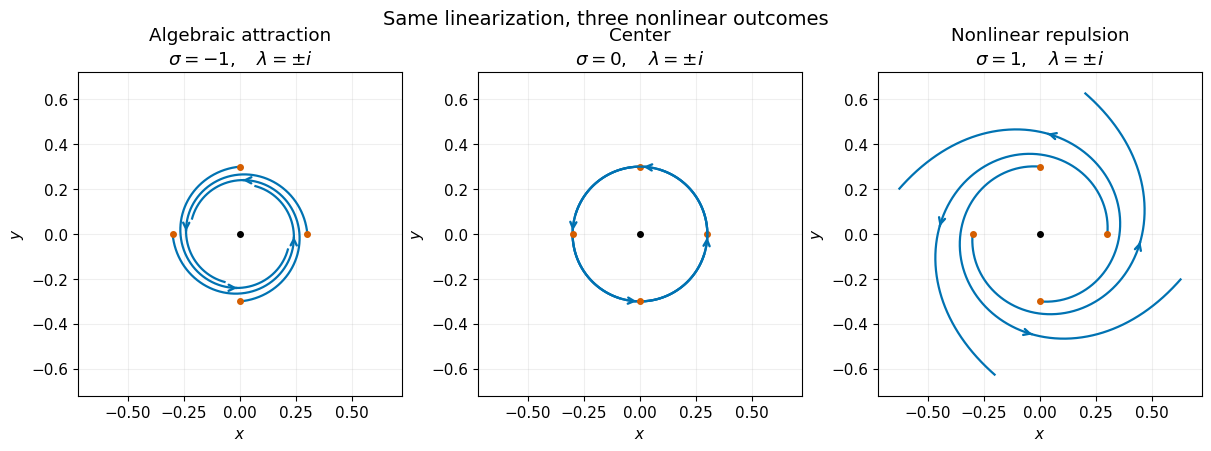

In [10]:
# planar-fixed-points-nonlinear-comparison
pf_fig, pf_axes = plt.subplots(1,3,figsize=(12,4.3),layout="constrained")
pf_r0 = .3
pf_times = np.linspace(0,4.4,900)
pf_radii = []
for pf_ax, pf_sigma, pf_en, pf_ua in zip(pf_axes,[-1,0,1],
        ["Algebraic attraction", "Center", "Nonlinear repulsion"],
        ["Алгебраїчне притягання", "Центр", "Нелінійне відштовхування"]):
    pf_r = pf_r0/np.sqrt(1-2*pf_sigma*pf_r0**2*pf_times)
    pf_radii.append(pf_r)
    for pf_phase in np.linspace(0,2*np.pi,4,endpoint=False):
        pf_theta = pf_phase+pf_times
        pf_x, pf_y = pf_r*np.cos(pf_theta), pf_r*np.sin(pf_theta)
        pf_ax.plot(pf_x,pf_y,color="#0072B2",lw=1.6)
        pf_ax.plot(pf_x[0],pf_y[0],"o",color="#D55E00",ms=4)
        pf_k = 620
        pf_ax.annotate("",xy=(pf_x[pf_k+12],pf_y[pf_k+12]),
            xytext=(pf_x[pf_k],pf_y[pf_k]),
            arrowprops=dict(arrowstyle="->",color="#0072B2",lw=1.7))
    pf_ax.plot(0,0,"ko",ms=4)
    pf_ax.set(xlim=(-.72,.72),ylim=(-.72,.72),xlabel="$x$",ylabel="$y$",
              title=pf_text(pf_en,pf_ua)+"\n"+fr"$\sigma={pf_sigma},\quad\lambda=\pm i$")
    pf_ax.set_aspect("equal")
    pf_ax.grid(alpha=.2)
pf_fig.suptitle(pf_text("Same linearization, three nonlinear outcomes",
                       "Однакова лінеаризація — три нелінійні режими"),fontsize=14)
plt.show()


### Worked connection and graphical investigation

For a damped oscillator $\ddot x+2\zeta\omega_0\dot x+\omega_0^2x=0$, with $\omega_0>0$ and $v=\dot x$,

$$A=\begin{pmatrix}0&1\\-\omega_0^2&-2\zeta\omega_0\end{pmatrix},\quad
T=-2\zeta\omega_0,\quad D=\omega_0^2,\quad Q=4\omega_0^2(\zeta^2-1).$$

For $0<\zeta<1$ the equilibrium is a stable focus (underdamping); for $\zeta>1$ it is a stable node (overdamping); $\zeta=1$ is a defective stable node (critical damping), and $\zeta=0$ is a linear center. Negative damping gives instability. This supplies a physical interpretation of the classification, rather than a list of names.

1. Before running the atlas, predict each matrix's $T$, $D$, $Q$ and eigenvalues. Place it on the trace–determinant diagram. Explain why the last three panels require more than a region label.
2. Change one atlas matrix to $A=\begin{pmatrix}-2&1\\1&-2\end{pmatrix}$. Find its eigenvector directions by hand, then compare with the plot. Reverse the off-diagonal signs of a focus matrix: what changes even though $T,D$ do not?
3. Sketch the oscillator's nullclines $v=0$ and $v=-\omega_0x/(2\zeta)$ for $\zeta\ne0$. Add arrows and compare $\zeta=0,0.3,1,2$. Identify which line has horizontal flow and which has vertical flow.
4. Relate the laser's nonlasing field–polarization block to this diagram: $T=-(\kappa+\gamma_\perp)$ and $D=\kappa\gamma_\perp-g^2D_0$. At threshold a zero eigenvalue appears, while the third eigenvalue is $-\gamma_\parallel$. Explain why this is not a Hopf crossing and why nonlinear saturation is needed above threshold.
5. Explain why the three nonlinear examples cannot be classified from their identical eigenvalues. Use $\dot r$ to justify each conclusion. A picture supports the argument but does not replace it.

**Reading and figure provenance.** Stephen Lynch, *Dynamical Systems with Applications using Mathematica*, 2nd ed. (2017), Chapter 3, especially §§3.1–3.4 and Fig. 3.5, [DOI](https://doi.org/10.1007/978-3-319-61485-4). In the supplied local PDF these sections are around PDF pages 62–75 (printed pages 46–59). See also [MIT OCW: Trace–Determinant Diagram](https://ocw.mit.edu/courses/18-03sc-differential-equations-fall-2011/resources/mit18_03scf11_s34_5text/). The figures here are newly generated from the displayed equations; no textbook figures are reproduced. The cells use NumPy and Matplotlib and can be rerun in Colab without the local PDF.


## Linear stability and normal forms

Writing $\mathbf{x}=\mathbf{x}_*+\boldsymbol\xi$ gives $\dot{\boldsymbol\xi}=J_*\boldsymbol\xi+O(\|\boldsymbol\xi\|^2)$. A local bifurcation occurs when an eigenvalue crosses the imaginary axis. Normal forms retain the lowest-order terms that cannot be removed by smooth changes of variables.

| Transition | Normal form | Key scaling |
|---|---|---|
| Saddle-node | $\dot x=\mu-x^2$ | $x_*\sim\mu^{1/2}$ |
| Transcritical | $\dot x=\mu x-x^2$ | branches exchange stability |
| Supercritical pitchfork | $\dot x=\mu x-x^3$ | $|x_*|\sim\mu^{1/2}$ |
| Supercritical Hopf | $\dot z=(\mu+i\omega)z-|z|^2z$ | $|z|\sim\mu^{1/2}$ |

For the pitchfork, the stable-side relaxation rate tends to zero as $\mu\to0$: this is critical slowing down.


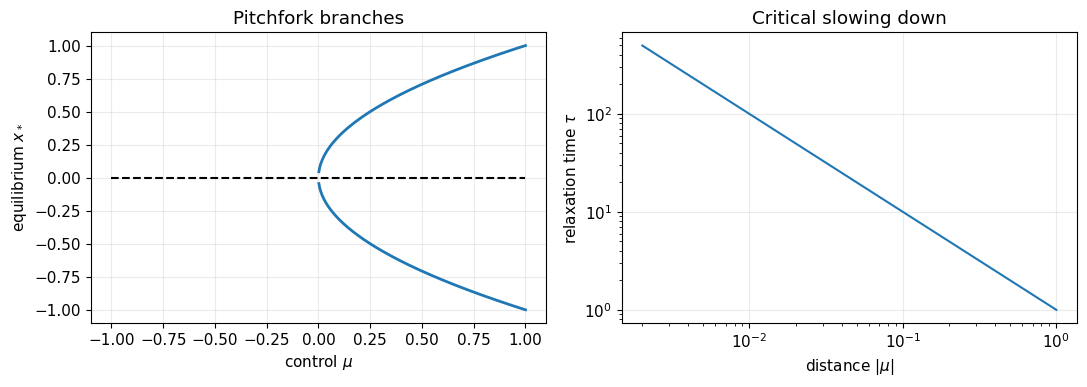

In [11]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.figsize": (7.2, 4.2),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.size": 11,
})
rng = np.random.default_rng(20260904)

mu = np.linspace(-1.0, 1.0, 500)

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(mu, np.zeros_like(mu), "k--", label="x=0")
positive = mu >= 0
ax[0].plot(mu[positive], np.sqrt(mu[positive]), "C0", lw=2)
ax[0].plot(mu[positive], -np.sqrt(mu[positive]), "C0", lw=2)
ax[0].set(xlabel=r"control $\mu$", ylabel=r"equilibrium $x_*$", title="Pitchfork branches")

tau_below = 1 / np.maximum(np.abs(mu[mu < 0]), 1e-12)
ax[1].loglog(-mu[mu < 0], tau_below)
ax[1].set(xlabel=r"distance $|\mu|$", ylabel=r"relaxation time $\tau$", title="Critical slowing down")
plt.tight_layout()


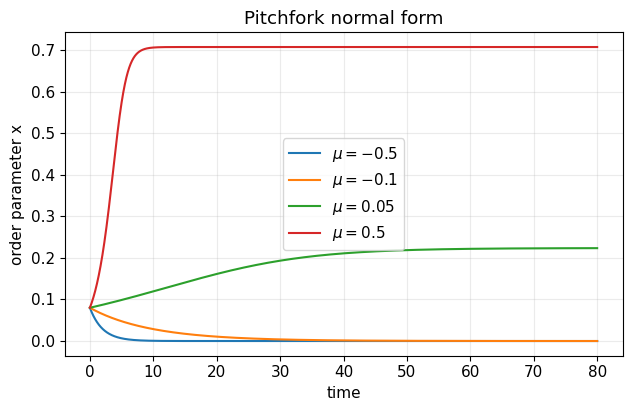

In [12]:
def rk4_scalar(f, x0, t, parameter):
    x = np.empty_like(t)
    x[0] = x0
    for n, dt in enumerate(np.diff(t)):
        k1 = f(x[n], parameter)
        k2 = f(x[n] + dt*k1/2, parameter)
        k3 = f(x[n] + dt*k2/2, parameter)
        k4 = f(x[n] + dt*k3, parameter)
        x[n+1] = x[n] + dt*(k1 + 2*k2 + 2*k3 + k4)/6
    return x

t = np.linspace(0, 80, 4001)
for m in [-0.5, -0.1, 0.05, 0.5]:
    trajectory = rk4_scalar(lambda x, mu_: mu_*x - x**3, 0.08, t, m)
    plt.plot(t, trajectory, label=fr"$\mu={m}$")
plt.xlabel("time")
plt.ylabel("order parameter x")
plt.title("Pitchfork normal form")
plt.legend()
plt.show()


## Self-oscillations: energy from a steady source

A **self-sustained oscillation** is a stable periodic regime whose amplitude and period are selected by the system's internal nonlinear dynamics rather than by a periodic external force. Free oscillations decay through friction; forced oscillations follow an imposed rhythm; a self-oscillator draws energy from a steady source and regulates that input during every cycle. It is therefore the simplest temporal structure in an open dissipative system.

Balthasar van der Pol's classical model arose from the theory of a triode oscillator:

$$\ddot x-\mu(1-x^2)\dot x+\omega_0^2x=0,\qquad \mu>0.$$

With $v=\dot x$,

$$\dot x=v,\qquad \dot v=\mu(1-x^2)v-\omega_0^2x.$$

Near the origin, the coefficient multiplying $v$ is positive: a small fluctuation grows, so the resting state is unstable. At large $|x|$, the effective damping changes sign and removes energy. For

$$E=\frac12\left(v^2+\omega_0^2x^2\right),$$

direct differentiation gives

$$\dot E=\mu(1-x^2)v^2.$$

Energy is injected on average at small amplitude and dissipated at large amplitude. A stable **limit cycle** is selected when $\langle\dot E\rangle=0$ over one period. Its existence does not imply zero dissipation: the steady source continually compensates losses through nonlinear feedback.

> **Synergetic interpretation.** A steady energy flux sustains the instability of rest, nonlinearity limits growth, and the system selects a macroscopic rhythm. The cycle's phase is neutral, providing the later bridge to synchronization.


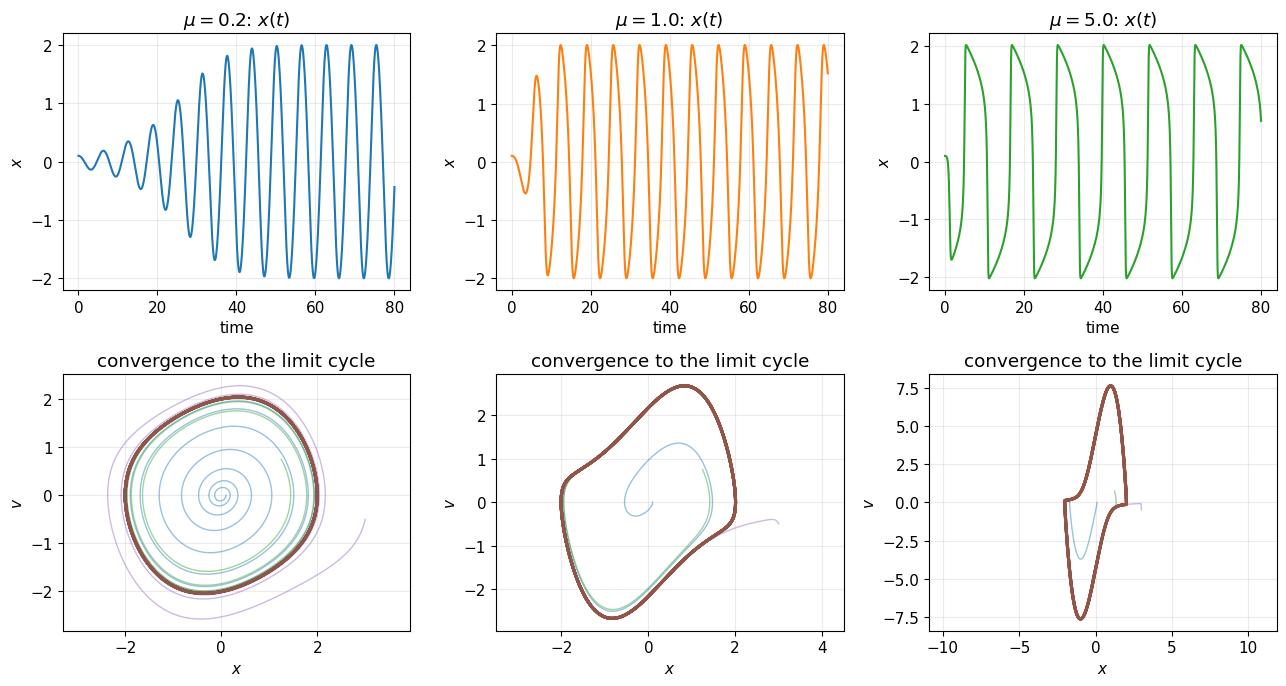

In [13]:
from scipy.integrate import solve_ivp

def van_der_pol(t, state, mu, omega0=1.0):
    x, v = state
    return v, mu * (1.0 - x**2) * v - omega0**2 * x

mus = [0.2, 1.0, 5.0]
initial_states = [(0.10, 0.0), (1.25, 0.75), (3.0, -0.5)]
t_eval = np.linspace(0.0, 80.0, 8001)

fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for column, mu_value in enumerate(mus):
    reference = None
    for state0 in initial_states:
        sol = solve_ivp(
            van_der_pol, (t_eval[0], t_eval[-1]), state0,
            args=(mu_value,), t_eval=t_eval, method="DOP853",
            rtol=1e-8, atol=1e-10, max_step=0.04,
        )
        axes[1, column].plot(sol.y[0], sol.y[1], alpha=0.45, lw=1.0)
        tail = sol.t > 0.75 * sol.t[-1]
        axes[1, column].plot(sol.y[0, tail], sol.y[1, tail], lw=2.2)
        if state0 == initial_states[0]:
            reference = sol

    axes[0, column].plot(reference.t, reference.y[0], color=f"C{column}")
    axes[0, column].set(
        title=fr"$\mu={mu_value}$: $x(t)$", xlabel="time", ylabel="$x$",
    )
    axes[1, column].set(
        title="convergence to the limit cycle", xlabel="$x$", ylabel="$v$",
    )
    axes[1, column].set_aspect("equal", adjustable="datalim")

plt.tight_layout()
plt.show()


In [ ]:
from scipy.signal import find_peaks

def cycle_diagnostics(mu_value, t_end=220.0):
    sample_times = np.linspace(0.0, t_end, 22001)
    sol = solve_ivp(
        van_der_pol, (0.0, t_end), (0.15, 0.0),
        args=(mu_value,), t_eval=sample_times, method="DOP853",
        rtol=1e-9, atol=1e-11, max_step=0.04,
    )
    mask = sol.t > 0.60 * t_end
    time_tail = sol.t[mask]
    x_tail, v_tail = sol.y[:, mask]
    peak_indices, _ = find_peaks(x_tail, prominence=0.2)
    cycle_peaks = peak_indices[-6:]
    period = np.mean(np.diff(time_tail[cycle_peaks]))
    cycle_slice = slice(cycle_peaks[0], cycle_peaks[-1] + 1)
    cycle_time = time_tail[cycle_slice]
    cycle_x, cycle_v = x_tail[cycle_slice], v_tail[cycle_slice]
    amplitude = 0.5 * (np.max(cycle_x) - np.min(cycle_x))
    power = mu_value * (1.0 - cycle_x**2) * cycle_v**2
    mean_power = np.trapezoid(power, cycle_time) / (cycle_time[-1] - cycle_time[0])
    return amplitude, period, mean_power

mu_scan = np.array([0.1, 0.2, 0.5, 1.0, 2.0, 5.0])
diagnostics = np.array([cycle_diagnostics(value) for value in mu_scan])

print("   mu     amplitude      period     <dE/dt>")
for value, (amplitude, period, mean_power) in zip(mu_scan, diagnostics):
    print(f"{value:5.2f}    {amplitude:8.4f}    {period:8.4f}    {mean_power: .2e}")

fig, ax = plt.subplots(1, 3, figsize=(13, 3.6))
ax[0].plot(mu_scan, diagnostics[:, 0], "o-")
ax[0].set(xlabel=r"$\mu$", ylabel="amplitude", title="Cycle size")
ax[1].plot(mu_scan, diagnostics[:, 1], "o-", color="C1")
ax[1].set(xlabel=r"$\mu$", ylabel="period", title="Relaxation-cycle slowdown")
ax[2].axhline(0.0, color="k", lw=1)
ax[2].plot(mu_scan, diagnostics[:, 2], "o-", color="C2")
ax[2].set(xlabel=r"$\mu$", ylabel=r"$\langle\dot E\rangle$", title="Energy balance")
plt.tight_layout()
plt.show()


## Model family and limits of the analogy

| Model | Equation or structure | What it adds |
|---|---|---|
| Rayleigh | $\ddot x+\omega_0^2x=\varepsilon(1-\dot x^2/3)\dot x$ | Nonlinear energy input and loss depend on velocity rather than displacement. |
| Liénard | $\ddot x+f(x)\dot x+g(x)=0$ | A general planar framework; under additional conditions Liénard's theorem guarantees one stable limit cycle. |
| Stuart–Landau | $\dot Z=(\lambda+i\omega)Z-(1+ic)|Z|^2Z$ | The normal form of a soft Hopf bifurcation; for $\lambda>0$, the amplitude approaches $|Z|=\sqrt{\lambda}$. |
| FitzHugh–Nagumo | fast activator + slow recovery | The transition between self-oscillation and excitability in a minimal language for nerve impulses and active media. |

For $0<\mu\ll1$, the Van der Pol oscillator is nearly harmonic and the nonlinearity slowly regulates its amplitude. For $\mu\gg1$, **relaxation oscillations** appear: slow motion along attracting branches alternates with fast jumps. The numerical problem becomes stiff, so results should be checked with a smaller maximum step or an implicit solver.

Under weak coupling, a stable limit cycle rapidly restores amplitude after perturbation while its phase remains slow. This supports phase reduction and the Kuramoto models in Module 08. Do not transfer the parameter $\mu$ literally from a triode oscillator to a heart, neuron, or chemical reaction: the systems can share dynamical geometry without sharing a microscopic mechanism.


## Investigation: how the system selects its own rhythm

1. For $\mu=0.2,1,5$, launch at least five initial states. Estimate convergence to one cycle and explain why coincident closed curves provide stronger evidence than one periodic time trace.
2. On the established cycle, integrate the positive and negative parts of $\dot E$ separately. Verify that they balance over a period even though neither part vanishes.
3. Replace the nonlinear damping by the Rayleigh form. Compare amplitude, period, waveform, and spectrum at equally weak nonlinearity.
4. Add weak forcing $A\cos\Omega t$. Map the frequency-locking region in the $(A,\Omega)$ plane and formulate the bridge from one self-oscillator to synchronization.

Separate numerical accuracy from physical interpretation in the report: show a step-size or tolerance check and name an observation that would falsify the claim of a stable limit cycle.


## Sources for self-oscillations

- B. van der Pol, [“On Relaxation-Oscillations”](https://doi.org/10.1080/14786442608564127), *The London, Edinburgh, and Dublin Philosophical Magazine and Journal of Science* **2**, 978–992 (1926).
- R. FitzHugh, [“Impulses and Physiological States in Theoretical Models of Nerve Membrane”](https://doi.org/10.1016/S0006-3495(61)86902-6), *Biophysical Journal* **1**, 445–466 (1961).
- [MIT OpenCourseWare: Forced Oscillators and Limit Cycles](https://ocw.mit.edu/courses/12-006j-nonlinear-dynamics-chaos-fall-2022/resources/mit12_006jf22_lec8-9/).
- S. H. Strogatz, *Nonlinear Dynamics and Chaos*, chapters on limit cycles, the Van der Pol oscillator, and weakly nonlinear oscillators.
- H. Haken, *Synergetics: An Introduction*, chapters on instabilities, Hopf bifurcation, and order parameters.


## Assessed exercise

For the Hopf normal form with a quintic correction, $\dot r=\mu r+ar^3-r^5$, map the stable and unstable cycles for both signs of $a$. Identify hysteresis, locate spinodals analytically, and verify them by forward/backward parameter sweeps.

Your submission must include a claim, the mathematical or physical reason for it, numerical evidence, and one limitation.


## Reading and attribution

**Local course reading:** Haken, *Synergetics: An Introduction*, instability chapters; Strogatz, *Nonlinear Dynamics and Chaos*, bifurcation chapters.

**Verified web reading:**
- [MIT OCW: Nonlinear Dynamics I](https://ocw.mit.edu/courses/18-353j-nonlinear-dynamics-i-chaos-fall-2012/)

The local books are course-provided sources. Web links are supplementary and were verified on 2026-09-04.
